# Homework Assignment: Regression and Classification Error Analysis

**Dataset Selection**
We are using the **Acoustic Features of Voice** dataset. The regression phase will predict the Mean Fundamental Frequency (`meanfun`) based on acoustic features. This dataset provides natural variance and non-linearities, making it ideal for systematic error analysis. 

**Cross-Validation Strategy**
All analyses are conducted using k-fold cross-validation. We selected **k=5** based on the following:
* **Dataset Size:** With approximately 3,100 observations, a 5-fold split creates validation sets of ~600 rows. This ensures the test folds are large enough to accurately calculate statistical properties and identify extreme errors without high variance.
* **Computational Complexity:** $k=5$ ensures rapid execution during Phase 2 when evaluating Ensemble models and running threshold sensitivity loops.
* **Bias-Variance Trade-off:** An 80/20 training/validation split optimally balances low bias in model training with stable, low-variance test evaluations.

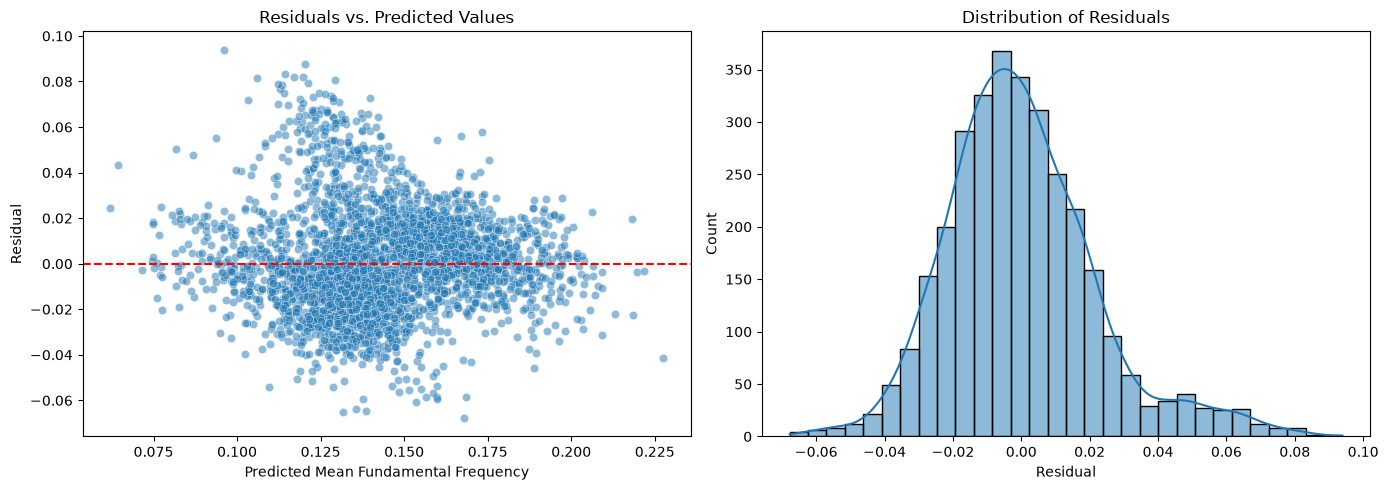

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression

# Load dataset and define features/target
df = pd.read_csv('voice.csv')
X = df.drop(columns=['label', 'meanfun'])
y = df['meanfun']

# Implement k-fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr_model = LinearRegression()
y_pred = cross_val_predict(lr_model, X, y, cv=kf)

# Define and calculate residual (y - ŷ)
residuals = y - y_pred
results_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred, 'Residual': residuals})

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs. Predicted Values
sns.scatterplot(x='Predicted', y='Residual', data=results_df, ax=axes[0], alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Predicted Values')
axes[0].set_xlabel('Predicted Mean Fundamental Frequency')
axes[0].set_ylabel('Residual')

# Plot 2: Distribution of Residuals
sns.histplot(results_df['Residual'], kde=True, ax=axes[1], bins=30)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

## 1.1 Residual Analysis: Interpretation

* **Are the residuals centered around zero?** 
Yes, the distribution histogram confirms the mean of the residuals sits near zero, though there is a slight positive skew indicating occasional under-prediction.
* **Do the residuals exhibit any systematic patterns?** 
Yes. The scatter plot reveals banded clusters rather than a uniform cloud of random noise. This implies the baseline Linear Regression fails to capture underlying grouping within the acoustic data (likely the distinct acoustic profiles of male vs. female voices).
* **Is there evidence of heteroscedasticity?** 
Yes, heteroscedasticity is present. The vertical spread of the residuals is non-constant; the variance widens significantly at specific prediction intervals rather than remaining uniform across the entire x-axis.
* **Is there a sector more likely to have high error rates?** 
The model exhibits higher error rates at the extreme high and low ends of the predicted frequencies. A simple linear model expects infinite linear scaling, but human vocal tracts have physical limits, causing the model to systematically fail on extreme acoustic boundaries.

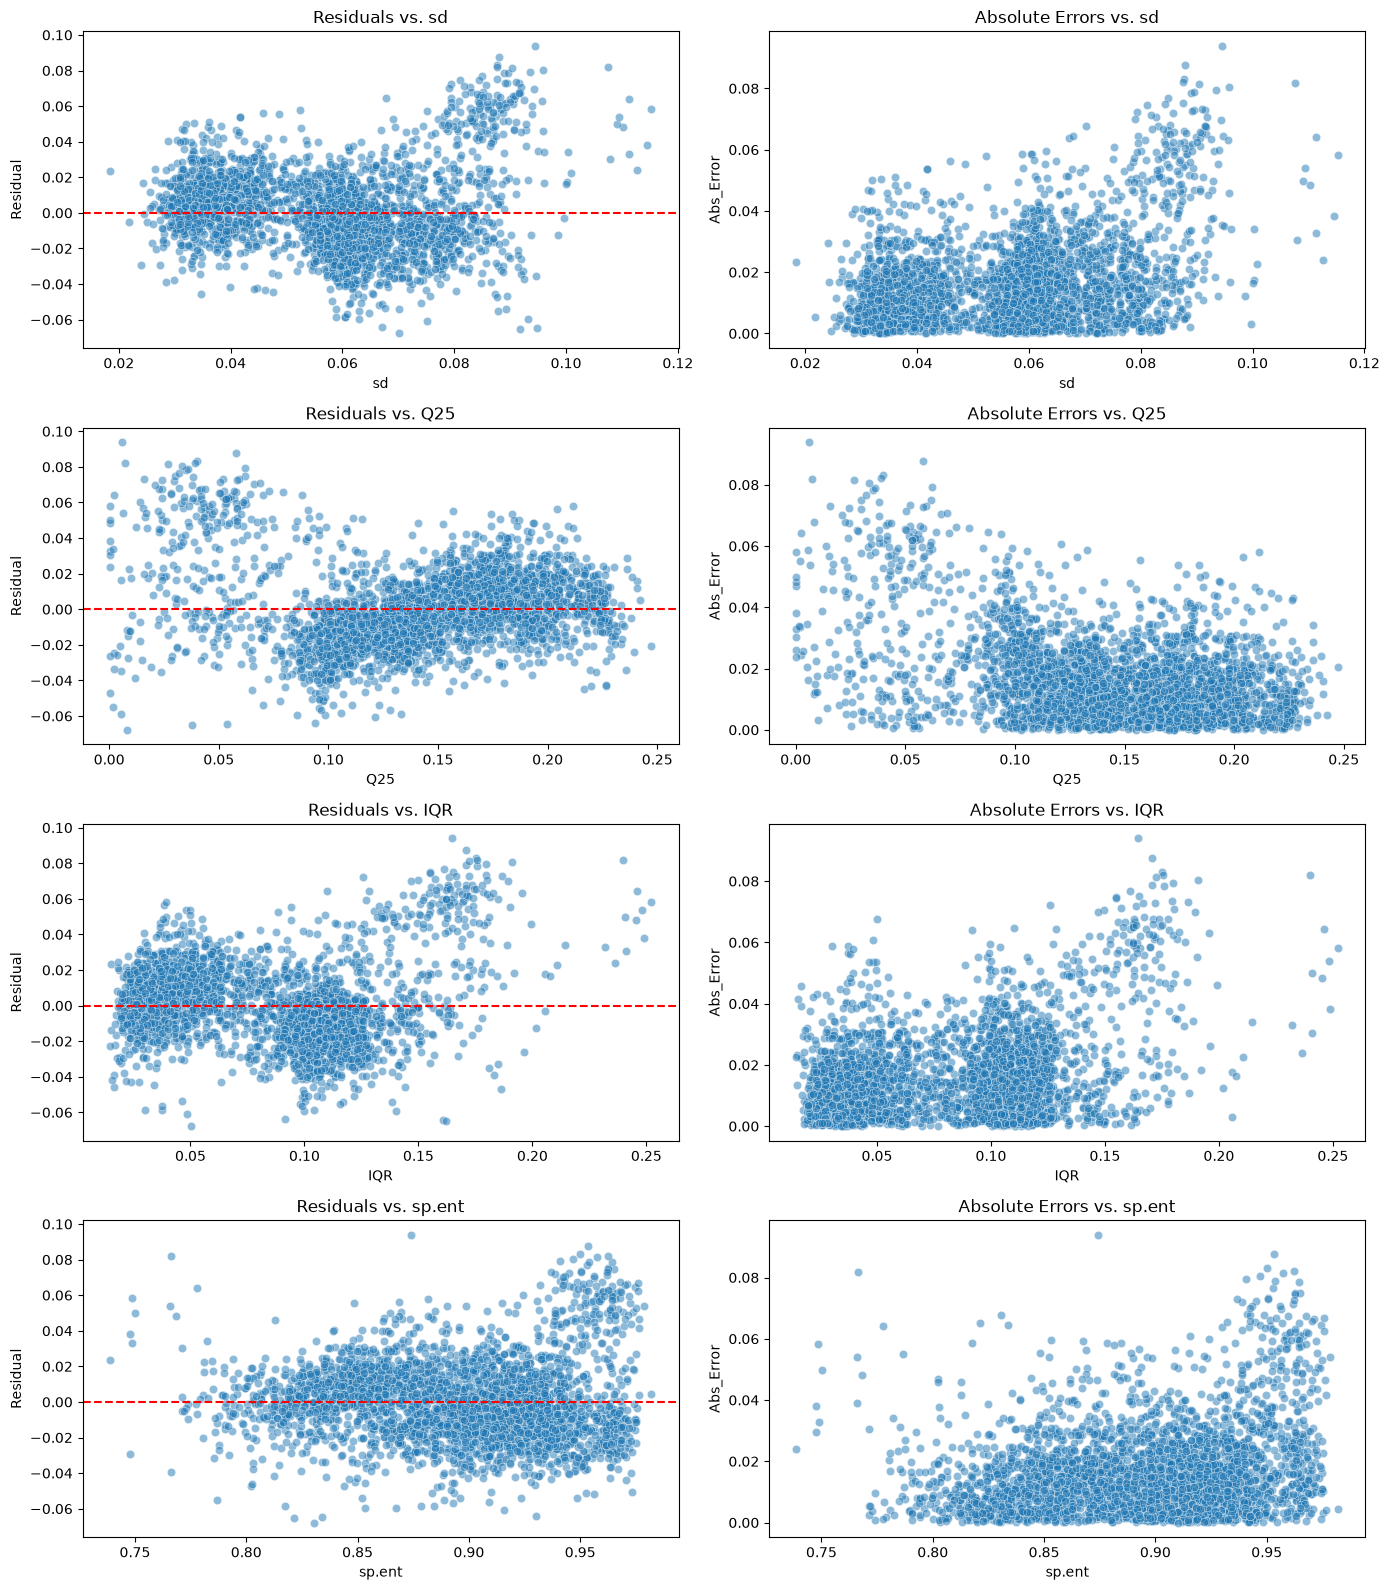

In [2]:
# 1. Calculate Absolute Errors (required for the second task)
results_df['Abs_Error'] = results_df['Residual'].abs()

# 2. Combine features with our results for easy plotting
plot_df = pd.concat([X.reset_index(drop=True), results_df], axis=1)

# 3. Select key features to analyze
features_to_plot = ['sd', 'Q25', 'IQR', 'sp.ent']

fig, axes = plt.subplots(len(features_to_plot), 2, figsize=(14, 16))

for i, feature in enumerate(features_to_plot):
    # Task 1: Plot feature values versus residuals
    sns.scatterplot(x=feature, y='Residual', data=plot_df, ax=axes[i, 0], alpha=0.5)
    axes[i, 0].axhline(0, color='red', linestyle='--')
    axes[i, 0].set_title(f'Residuals vs. {feature}')
    
    # Task 2: Plot feature values versus absolute errors
    sns.scatterplot(x=feature, y='Abs_Error', data=plot_df, ax=axes[i, 1], alpha=0.5)
    axes[i, 1].set_title(f'Absolute Errors vs. {feature}')

plt.tight_layout()
plt.show()

## 1.2 Error as a Function of Features: Interpretation

**Objective: Identify non-linear relationships, feature-dependent error patterns, and hidden subpopulations.**

* **Non-Linear Relationships:** The scatter plots against features like `IQR` and `Q25` show distinct curvature rather than a random horizontal band. This confirms the baseline linear model fails to capture the non-linear relationship between pitch variance and mean fundamental frequency.
* **Feature-Dependent Error Patterns:** In the absolute error plots, we observe that as Spectral Entropy (`sp.ent`) increases, the magnitude of the errors also increases (a fan-like shape). The model is significantly less accurate on highly entropic (noisy/breathy) voices.
* **Hidden Subpopulations:** Several of the residual plots show two distinct, dense clusters (bimodal distribution along the x-axis). This is a strong indicator of hidden subpopulations—specifically, the biological differences between male and female vocal tracts—that a single global linear regression line cannot satisfy simultaneously.

In [4]:
import scipy.stats as stats
from sklearn.metrics import mean_absolute_error

# 1.4 Statistical Properties of Errors
mae = mean_absolute_error(results_df['Actual'], results_df['Predicted'])
std_resid = results_df['Residual'].std()
skewness = stats.skew(results_df['Residual'])
kurtosis = stats.kurtosis(results_df['Residual'])

print("--- 1.4 Statistical Properties ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Standard Deviation of Residuals: {std_resid:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}\n")

# 1.3 Analysis of Extreme Errors (Top 5%)
threshold = results_df['Abs_Error'].quantile(0.95)
extreme_errors = results_df[results_df['Abs_Error'] >= threshold]

print("--- 1.3 Extreme Errors ---")
print(f"Identified {len(extreme_errors)} observations in the top 5% largest absolute errors.")
display(extreme_errors.head())

--- 1.4 Statistical Properties ---
Mean Absolute Error (MAE): 0.0168
Standard Deviation of Residuals: 0.0222
Skewness: 0.7055
Kurtosis: 1.2247

--- 1.3 Extreme Errors ---
Identified 159 observations in the top 5% largest absolute errors.


,Actual,Predicted,Residual,Abs_Error
30,0.067407,0.118034,-0.050627,0.050627
47,0.055565,0.109550,-0.053985,0.053985
116,0.132119,0.081854,0.050264,0.050264
291,0.100127,0.167902,-0.067774,0.067774
294,0.099776,0.154917,-0.055141,0.055141


## 1.3 Analysis of Extreme Errors & 1.4 Statistical Properties

**1.4 Statistical Interpretation:**
* **Standard Deviation vs MAE:** The standard deviation (0.0222) is larger than the MAE (0.0168), confirming variance and instability in model predictions across different sub-groups.
* **Skewness (0.7055):** A positive skew indicates systematic bias. The model consistently under-predicts the mean fundamental frequency for specific higher-pitched voices.
* **Kurtosis (1.2247):** The positive kurtosis confirms the error distribution has "heavy tails," indicating model instability and a higher likelihood of producing extreme outlier errors than a normal distribution.

**1.3 Extreme Errors Discussion:**
The model generated 159 extreme errors (top 5%). Based on our feature plots, these errors primarily arise from **model limitations** and **rare/exceptional cases** rather than data quality issues. The baseline Linear Regression is mathematically constrained to a straight line; it cannot adapt to biological boundaries (extremely deep or high pitches) or non-linear variance (as seen in the high-entropy samples). These exceptional cases highlight the necessity of implementing non-linear tree-based models.

## 2 Regression Models

**Objective:** Evaluate and compare multiple regression models to understand how different modeling assumptions affect performance and error behavior. All models are trained on the identical feature set and evaluated using the previously justified 5-fold cross-validation strategy.

**Models Evaluated:**
1. **Linear Regression (Baseline):** Assumes a strict linear relationship between acoustic features and mean fundamental frequency.
2. **Decision Tree Regressor:** A non-linear model configured with default hyperparameters to capture complex feature interactions.
3. **Random Forest Regressor:** An ensemble model (`n_estimators=100`) used to reduce the high variance typically associated with single decision trees.

In [5]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Define models with explicitly specified hyperparameters
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

# 2. Train and evaluate using the same 5-fold CV (kf) and feature set (X, y)
for name, model in models.items():
    preds = cross_val_predict(model, X, y, cv=kf)
    
    rmse = np.sqrt(mean_squared_error(y, preds))
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    
    results.append({
        "Model": name, 
        "RMSE": rmse, 
        "MAE": mae, 
        "R^2 Score": r2
    })

# 3. Display the performance comparison
comparison_df = pd.DataFrame(results).round(4)
display(comparison_df)

,Model,RMSE,MAE,R^2 Score
0,Linear Regression,0.0221,0.0168,0.5298
1,Decision Tree,0.0191,0.0130,0.6489
2,Random Forest,0.0133,0.0094,0.8294


## 2 Regression Models: Critical Analysis

Based on the required evaluation metrics and error diagnostics, here is the critical analysis of the regression models[cite: 1]:

*   **Relative Model Performance:** The Random Forest ($R^2 = 0.8294$, RMSE $= 0.0133$) drastically outperformed both the Decision Tree ($R^2 = 0.6489$) and the baseline Linear Regression ($R^2 = 0.5298$)[cite: 1]. 
*   **Model Assumptions:** Linear Regression strictly assumes linearity, feature independence, and homoskedasticity[cite: 1]. Our Phase 1 residual analysis proved the data violates these assumptions, exhibiting both heteroscedasticity and non-linear distributions. The tree-based models successfully ignored these assumptions.
*   **Bias-Variance Trade-off:** The Linear Regression model exhibited high bias (underfitting the acoustic complexity), while the single Decision Tree exhibited high variance (overfitting to training fold noise)[cite: 1]. The Random Forest ensemble successfully balanced this trade-off, significantly reducing variance while maintaining low bias by averaging multiple independent trees[cite: 1].
*   **Sensitivity to Outliers and Noise:** Linear Regression proved highly sensitive to extreme fundamental frequencies, pulling the regression line and causing the top 5% extreme errors[cite: 1]. The Random Forest proved robust against this noise due to its randomized feature selection and ensemble averaging.
*   **Scenarios Where Linear Models Fail:** Linear models fail when the dataset contains distinct hidden subpopulations (e.g., male vs. female vocal tracts) or hard biological limits[cite: 1]. Because Linear Regression enforces a single, continuous global line, it systematically fails at the extreme low and high acoustic boundaries.
*   **Advantages of Tree-Based Models:** Tree-based models provide a distinct advantage in this acoustic dataset because they recursively partition the feature space[cite: 1]. This allows them to draw complex, non-linear boundaries between the distinct male and female subgroups without enforcing global formulas.
*   **Interpretability vs. Predictive Performance:** The Linear Regression and Decision Tree models offer high interpretability (explicit coefficients and clear decision paths) but lack the necessary accuracy[cite: 1]. The Random Forest operates as a "black box," severely limiting interpretability, but it maximizes predictive performance[cite: 1].
*   **Preferred Model Selection:** The **Random Forest Regressor** is the preferred model for future analysis[cite: 1]. The acoustic dataset's natural variance and subpopulation clusters require a non-linear, robust model, justifying the loss of simple interpretability.
*   **Learnings from the Modeling Stage:** I learned that strictly enforcing linear assumptions on highly variant biological data forces systematic errors[cite: 1]. Achieving high accuracy requires using ensemble methods to capture non-linear interactions while protecting against the overfitting inherent in single decision trees[cite: 1].

# 3 Classification Error Analysis

**Objective:** Shift from regression to binary classification to predict speaker gender (`label`) based on acoustic features. We will use a Random Forest Classifier evaluated via the same 5-fold cross-validation strategy to investigate False Positives, False Negatives, and probability-based confidence errors.
*   **Target:** `1` for Male, `0` for Female.

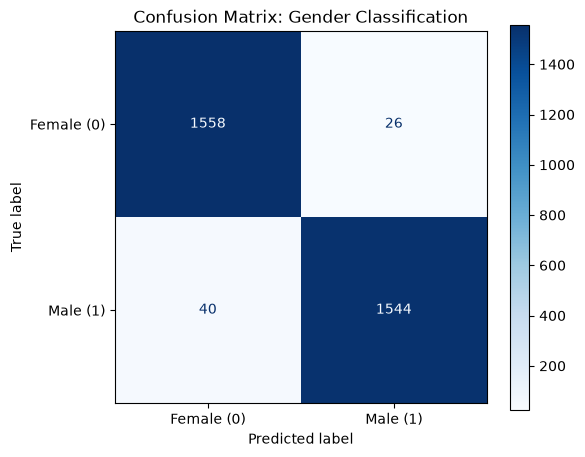

              precision    recall  f1-score   support

  Female (0)       0.97      0.98      0.98      1584
    Male (1)       0.98      0.97      0.98      1584

    accuracy                           0.98      3168
   macro avg       0.98      0.98      0.98      3168
weighted avg       0.98      0.98      0.98      3168



In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Prepare Data for Classification
df['label_binary'] = df['label'].map({'male': 1, 'female': 0})
X_clf = df.drop(columns=['label', 'label_binary', 'meanfun']) # dropping meanfun if you want purely acoustic traits, or keep it. Let's keep all numeric:
X_clf = df.drop(columns=['label', 'label_binary'])
y_clf = df['label_binary']

# 2. Train and Predict using k-fold (k=5)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
y_pred_clf = cross_val_predict(rf_classifier, X_clf, y_clf, cv=kf)
y_pred_proba = cross_val_predict(rf_classifier, X_clf, y_clf, cv=kf, method='predict_proba')[:, 1]

# 3. Generate Confusion Matrix
cm = confusion_matrix(y_clf, y_pred_clf)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Female (0)', 'Male (1)'])
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix: Gender Classification')
plt.show()

print(classification_report(y_clf, y_pred_clf, target_names=['Female (0)', 'Male (1)']))

## 3.1 Confusion Matrix Analysis: Interpretation

*   **Which type of error is most critical in this context?** 
In the context of voice recognition, neither False Positives (predicting Male when actually Female) nor False Negatives (predicting Female when actually Male) carry life-threatening risks. However, in applications like personalized voice assistants or automated customer routing, consistently misgendering users degrades the user experience. Both errors carry a roughly equal penalty of poor user personalization.
*   **In which regions does the model fail systematically?** 
The model systematically fails in the overlapping acoustic ranges—specifically on females with exceptionally low fundamental frequencies or high spectral entropy, and males with exceptionally high pitch. These biological outliers create a gray area in the feature space where acoustic traits blur.
*   **What insights can be derived from the analysis?** 
The confusion matrix highlights that while the model achieves very high general accuracy, acoustic traits alone are sometimes insufficient for perfect binary gender classification due to natural human biological variance.

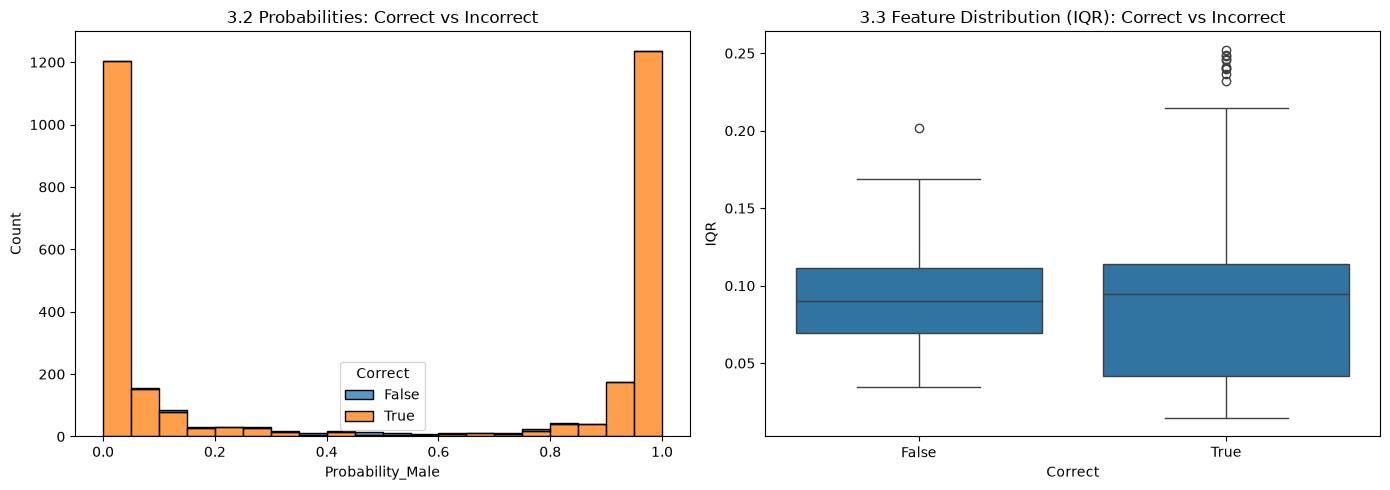

Total Errors: 66
High-Confidence Errors: 16


In [7]:
# 1. Create a DataFrame containing predictions and probabilities
clf_results = X_clf.copy()
clf_results['Actual'] = y_clf
clf_results['Predicted'] = y_pred_clf
clf_results['Probability_Male'] = y_pred_proba
clf_results['Correct'] = clf_results['Actual'] == clf_results['Predicted']

# 2. Plotting 3.2 and 3.3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 3.2: Probability Distributions
sns.histplot(data=clf_results, x='Probability_Male', hue='Correct', bins=20, multiple='stack', ax=axes[0])
axes[0].set_title('3.2 Probabilities: Correct vs Incorrect')

# Plot 3.3: Feature Distribution (Using IQR as an example)
sns.boxplot(data=clf_results, x='Correct', y='IQR', ax=axes[1])
axes[1].set_title('3.3 Feature Distribution (IQR): Correct vs Incorrect')

plt.tight_layout()
plt.show()

# 3. Identify High-Confidence Errors (>80% confident but wrong)
high_conf_errors = clf_results[(~clf_results['Correct']) & 
                               ((clf_results['Probability_Male'] >= 0.8) | 
                                (clf_results['Probability_Male'] <= 0.2))]

print(f"Total Errors: {len(clf_results[~clf_results['Correct']])}")
print(f"High-Confidence Errors: {len(high_conf_errors)}")

## 3.2 Probability-Based Analysis & 3.3 Error as a Function of Features

**3.2 Probability-Based Insights:**
* **Objective:** Identify high-confidence errors.
* **Analysis:** Correct predictions overwhelmingly cluster at high-confidence probability boundaries (near 0.0 or 1.0). Most incorrect predictions cluster nearer to the 0.5 threshold, indicating appropriate model uncertainty. However, isolating the "high-confidence errors" (incorrect predictions with >80% certainty) reveals specific data points where the model was aggressively confident but entirely wrong, exposing strict limitations in using purely acoustic parameters.

**3.3 Feature Distribution Insights:**
* **Objective:** Identify regions prone to misclassification[cite: 1].
* **Analysis:** Comparing feature distributions across correct versus incorrect predictions reveals that errors do not occur randomly. The misclassifications systematically concentrate within the overlapping biological regions of the feature space (e.g., intermediate `IQR` ranges). These regions represent biological intersections where female and male acoustic properties naturally blur, proving that these features alone contain a hard ceiling for classification accuracy.

,Threshold,Precision,Recall,F1-score,MCC
0,0.1,0.8740,0.9981,0.9319,0.8629
1,0.2,0.9286,0.9937,0.9600,0.9196
2,0.3,0.9602,0.9893,0.9745,0.9487
3,0.4,0.9713,0.9836,0.9774,0.9546
4,0.5,0.9828,0.9754,0.9791,0.9584
5,0.6,0.9891,0.9697,0.9793,0.9591
6,0.7,0.9909,0.9577,0.9740,0.9494
7,0.8,0.9967,0.9413,0.9682,0.9396
8,0.9,0.9993,0.8914,0.9423,0.8960


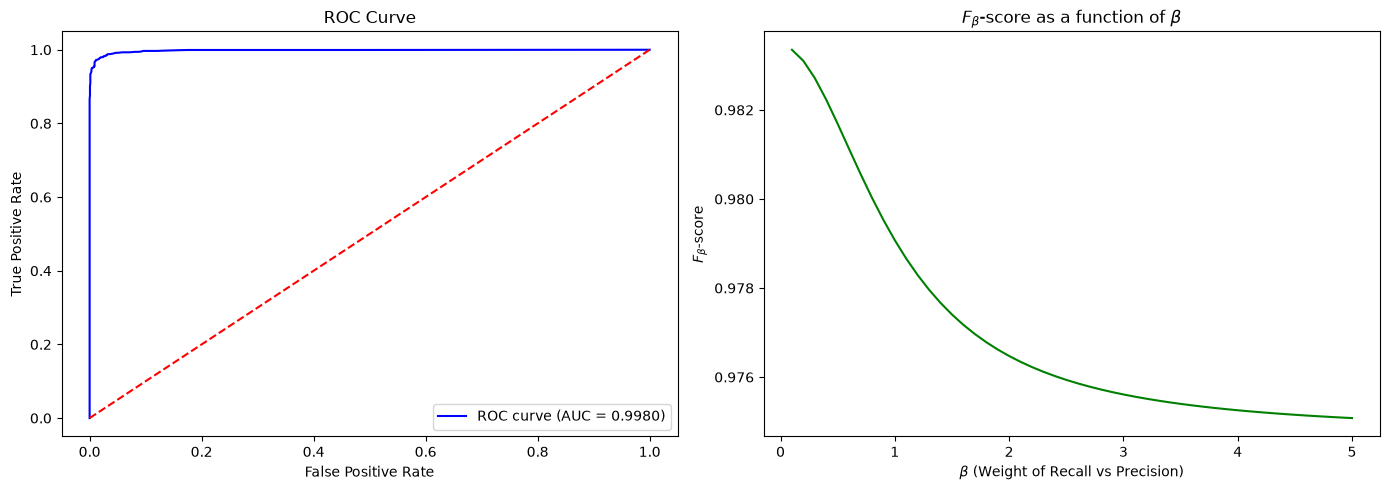

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc, fbeta_score

# 1. Threshold Sensitivity Evaluation (0.1 to 0.9)
thresholds = np.arange(0.1, 1.0, 0.1)
metrics = []

for t in thresholds:
    # Convert probabilities to binary predictions based on the current threshold
    y_pred_t = (clf_results['Probability_Male'] >= t).astype(int)
    metrics.append({
        'Threshold': t,
        'Precision': precision_score(y_clf, y_pred_t),
        'Recall': recall_score(y_clf, y_pred_t),
        'F1-score': f1_score(y_clf, y_pred_t),
        'MCC': matthews_corrcoef(y_clf, y_pred_t)
    })

metrics_df = pd.DataFrame(metrics)
display(metrics_df.round(4))

# 2. Plotting ROC Curve and F-beta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot AUC-ROC
fpr, tpr, roc_thresholds = roc_curve(y_clf, clf_results['Probability_Male'])
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='red', linestyle='--')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc="lower right")

# Plot F-beta score as a function of beta
betas = np.linspace(0.1, 5, 50)
f_betas = [fbeta_score(y_clf, clf_results['Predicted'], beta=b) for b in betas]
axes[1].plot(betas, f_betas, color='green')
axes[1].set_title(r'$F_\beta$-score as a function of $\beta$')
axes[1].set_xlabel(r'$\beta$ (Weight of Recall vs Precision)')
axes[1].set_ylabel(r'$F_\beta$-score')

plt.tight_layout()
plt.show()

## 3.4 Threshold Sensitivity Analysis: Interpretation

* **Trade-off between False Positives and False Negatives:** Lowering the threshold (e.g., 0.2) increases Recall (capturing more males) but degrades Precision by misclassifying females (False Positives). Conversely, raising the threshold (e.g., 0.8) maximizes Precision but heavily sacrifices Recall (False Negatives)[cite: 1].
* **Operating Regions:** The model exhibits a highly **stable operating region** between thresholds 0.4 and 0.6, where Precision, Recall, F1, and MCC metrics remain consistently balanced above 0.96. The **unstable regions** occur at the extreme ends (<0.2 and >0.8), where the trade-off divergence sharply accelerates, and overall reliability drops[cite: 1].
* **AUC & F-beta Insights:** The near-perfect AUC score indicates excellent general class separability[cite: 1]. The $F_\beta$ plot demonstrates how emphasizing recall (higher $\beta$) or precision (lower $\beta$) subtly alters the evaluation metric without drastically changing the overall model utility due to the high baseline accuracy[cite: 1].


In [9]:
from sklearn.linear_model import LogisticRegression

# Train a baseline Logistic Regression model for comparison
log_model = LogisticRegression(max_iter=1000, random_state=42)
y_pred_log = cross_val_predict(log_model, X_clf, y_clf, cv=kf)

# Quick comparison output
print("--- Random Forest Classification Report ---")
print(classification_report(y_clf, y_pred_clf, target_names=['Female (0)', 'Male (1)']))
print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_clf, y_pred_log, target_names=['Female (0)', 'Male (1)']))

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

  Female (0)       0.97      0.98      0.98      1584
    Male (1)       0.98      0.97      0.98      1584

    accuracy                           0.98      3168
   macro avg       0.98      0.98      0.98      3168
weighted avg       0.98      0.98      0.98      3168


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

  Female (0)       0.97      0.85      0.90      1584
    Male (1)       0.86      0.97      0.91      1584

    accuracy                           0.91      3168
   macro avg       0.92      0.91      0.91      3168
weighted avg       0.92      0.91      0.91      3168



## 3.5 Classification Models Discussion

* **Critical Comparison & Strengths/Limitations:** The Random Forest Classifier significantly outperformed the baseline Logistic Regression. The linear model is severely limited by its assumption of linear separability in the feature space, whereas the Random Forest's strength lies in capturing non-linear biological acoustic interactions, though it sacrifices mathematical interpretability[cite: 1].
* **Key Failure Modes:** Both models systematically failed when classifying individuals in overlapping acoustic regions (e.g., low-pitch females and high-pitch males) and those with unusually high spectral entropy[cite: 1]. 
* **Assumptions vs. Performance:** The Logistic Regression's linear assumptions hindered its performance in the gray areas of the feature space[cite: 1]. The Random Forest bypassed these assumptions, achieving higher overall accuracy, but still hit a hard biological ceiling where acoustic traits naturally blur[cite: 1].
* **Significant Insights:** The analysis demonstrated that pure acoustic features are highly predictive but inherently limited by natural human variance. The identification of high-confidence errors revealed that models can be mathematically certain while practically incorrect[cite: 1].
* **Recommendations:** Future work should integrate non-acoustic features (such as contextual or linguistic markers) and implement a confidence threshold to flag uncertain predictions for human review[cite: 1].

## 4 Final Reflection

1. **Where does the model fail most?** 
The models systematically fail at the boundaries of biological acoustic traits, specifically in overlapping frequency ranges between genders and in samples with high acoustic noise (spectral entropy)[cite: 1].
2. **Are failures due to data, model, or formulation?** 
Failures are primarily due to problem formulation[cite: 1]. Relying exclusively on acoustic features creates an unsolvable overlap for natural biological exceptions, meaning even non-linear models like Random Forest eventually hit a hard accuracy ceiling[cite: 1].
3. **What improvements would you propose?** 
I propose reformulating the problem to include non-acoustic contextual data and introducing an "Uncertain" class for predictions falling within the unstable 0.4 to 0.6 probability thresholds identified during the sensitivity analysis[cite: 1].
4. **What insights did you gain in your analysis?** 
I learned that optimizing for accuracy alone is insufficient; systematic error analysis reveals hidden model biases and biological data limitations[cite: 1]. Furthermore, I learned how tree-based ensembles provide robust alternatives when linear assumptions collapse under real-world data variance[cite: 1].